In [21]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense

from utils import one_hot_encode, apply_pca

RANDOM_STATE = 36
SEED = 143

In [22]:
df = pd.read_csv('Housing.csv')
print(df.shape)
df.head()

(545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Removing Irrelevant Data

In [23]:
# df = df.drop(['basement', 'hotwaterheating', 'guestroom', 'mainroad', 'furnishingstatus'], axis=1)
# df.head()

In [24]:
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

# One Hot Encoding

In [25]:
columns_to_encode = [x for x in df.columns if df[x].dtype == 'str']
df = one_hot_encode(df, *columns_to_encode)
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,...,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
1,12250000,8960,4,4,4,3,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0
2,12250000,9960,3,2,2,2,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,12215000,7500,4,2,2,3,0.0,1.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0
4,11410000,7420,4,1,2,2,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0


# Decreasing Features for Visualization
## With Applying PCA

In [26]:
df_pca, pca = apply_pca(df)
print('Shape:', df_pca.shape, '\nVariance Ratio:', pca.explained_variance_ratio_)


Shape: (545, 2) 
Variance Ratio: [9.99999041e-01 9.59397790e-07]


# Visualizing using PCA

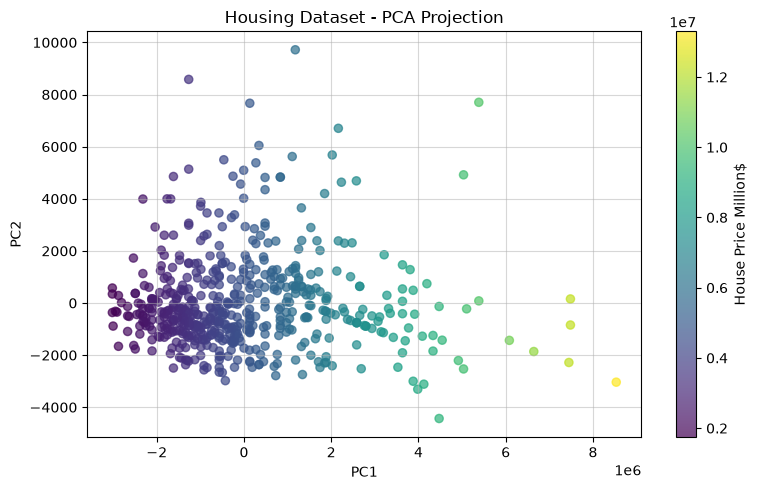

In [27]:
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=df["price"],
    cmap="viridis",
    alpha=0.7,
    s=35
)

plt.xlabel(f"PC1")
plt.ylabel(f"PC2")
plt.title("Housing Dataset - PCA Projection")

plt.colorbar(scatter, label="House Price Million$")
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

# Train/Val Splitting Data

In [28]:
y = df['price']
x = df.drop('price', axis=1)

x_train, x_cv, y_train, y_cv = train_test_split(x, y, test_size=0.2, random_state=RANDOM_STATE)
print(x_train.shape, y_train.shape, x_cv.shape, y_cv.shape)
print('Standard Deviation of Area:', x_train['area'].std())

(436, 20) (436,) (109, 20) (109,)
Standard Deviation of Area: 2186.470781292045


# Scaling Data

In [29]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_cv_scaled = scaler.transform(x_cv)
print(x_train_scaled.std())

1.0


# Training Model

In [30]:
tf.random.set_seed(SEED)
model = tf.keras.Sequential([
    tf.keras.Input(shape=(20,)),
    Dense(128, activation='relu', name='L1'),
    Dense(64, activation='relu', name='L2'),
    Dense(32, activation='relu', name='L3'),
    Dense(1, activation='linear', name='L4'),
], name='model_1')

model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,057 (51.00 KB)

 Trainable params: 13,057 (51.00 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.compile(
    loss = tf.keras.losses.MeanSquaredError(),
    optimizer = tf.keras.optimizers.Adam(0.1)
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=40,
)

history = model.fit(
    x_train_scaled,  y_train,
    epochs=100,
    validation_data=(x_cv_scaled, y_cv),
    callbacks=[early_stopping]
)

Epoch 1/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1001964765184.0000 - val_loss: 1139184369664.0000
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 831449399296.0000 - val_loss: 1185480835072.0000
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 783012528128.0000 - val_loss: 1185099022336.0000
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 777745334272.0000 - val_loss: 1189043240960.0000
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 773848825856.0000 - val_loss: 1191816986624.0000
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 764949495808.0000 - val_loss: 1201675960320.0000
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 762732412928.0000 - val_loss: 1208748867584.0000
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 757013872640.0000 - val_loss: 1213767483392.0000
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 753814732800.0000 - val_loss: 1219611066368.0000
Epoch 10/100
14/14

In [58]:
val_loss = history.history['val_loss']
loss = history.history['loss']

print('Number of digits for val_loss:', len(str(val_loss[-1])))
print('Number of digits for loss:', len(str(loss[-1])))

y_shame = y_train[np.argmax(y_train.to_numpy())]

print('Number of digits for the largest number in y_train:', len(str(y_shame)))
print('Dude You are Way OFF :((')

Number of digits for val_loss: 15
Number of digits for loss: 14
Number of digits for the largest number in y_train: 7
Dude You are Way OFF :((
